# Titanic — Pipeline Completo

Estrutura do notebook:
1. Importações
2. Carregamento dos dados
3. Engenharia de atributos
4. Tratamento de valores nulos
5. Preparação das variáveis
5b. Seleção de atributos (RFECV)
6. Ajuste de hiperparâmetros de cada modelo
7. Conjunto de modelos final (Votação + Empilhamento)
8. Geração da submissão

In [1]:
# ── 1. Importações ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import RFECV

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

ESTADO_ALEATORIO = 42
VC = StratifiedKFold(n_splits=5, shuffle=True, random_state=ESTADO_ALEATORIO)

In [2]:
# ── 2. Carregamento dos dados ─────────────────────────────────────────────────
treino = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
teste  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print(f"Treino: {treino.shape} | Teste: {teste.shape}")
treino.head()

Treino: (891, 12) | Teste: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# ── 3. Engenharia de atributos ────────────────────────────────────────────────
# Todas as transformações são aplicadas no treino e no teste simultaneamente

def criar_atributos(df):
    # --- Tamanho da família ---
    df["TamanhoFamilia"] = df["SibSp"] + df["Parch"] + 1
    df["Sozinho"]        = (df["TamanhoFamilia"] == 1).astype(int)

    # Categoria do tamanho da família: sozinho / pequena / grande
    df["GrupoFamilia"] = pd.cut(
        df["TamanhoFamilia"],
        bins=[0, 1, 4, 20],
        labels=["sozinho", "pequena", "grande"]
    ).astype(str)

    # --- Título extraído do nome ---
    df["Titulo"] = df["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df["Titulo"] = df["Titulo"].replace(
        ['Lady','Countess','Capt','Col','Don','Dr',
         'Major','Rev','Sir','Jonkheer','Dona'], 'Raro'
    )
    df["Titulo"] = df["Titulo"].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # --- Cabine ---
    df["TemCabine"]  = df["Cabin"].notna().astype(int)
    df["DeckCabine"] = df["Cabin"].str[0].fillna("D")  # A-G ou D(esconhecido)

    # --- Frequência do bilhete (proxy de grupo de viagem) ---
    contagem_bilhetes = df["Ticket"].value_counts()
    df["FreqBilhete"] = df["Ticket"].map(contagem_bilhetes)

    # --- Tarifa por pessoa (evita distorção em grupos grandes) ---
    df["TarifaPorPessoa"] = df["Fare"] / df["FreqBilhete"]

    # --- Faixas de idade e tarifa ---
    df["FaixaIdade"] = pd.cut(
        df["Age"], bins=[0, 12, 18, 35, 60, 100],
        labels=["crianca", "adolescente", "adulto", "meia-idade", "idoso"]
    ).astype(str)
    df["FaixaTarifa"] = pd.qcut(
        df["Fare"], q=4,
        labels=["baixa", "media", "alta", "muito-alta"]
    ).astype(str)

    return df

treino = criar_atributos(treino)
teste  = criar_atributos(teste)

print("Atributos criados:", [c for c in treino.columns if c not in [
    'PassengerId','Survived','Name','Sex','Age','SibSp','Parch',
    'Ticket','Fare','Cabin','Embarked','Pclass'
]])

Atributos criados: ['TamanhoFamilia', 'Sozinho', 'GrupoFamilia', 'Titulo', 'TemCabine', 'DeckCabine', 'FreqBilhete', 'TarifaPorPessoa', 'FaixaIdade', 'FaixaTarifa']


In [4]:
# ── 4. Tratamento de valores nulos ────────────────────────────────────────────

# Idade: mediana por Classe + Sexo calculada apenas no treino (sem vazamento de dados)
mediana_idade = treino.groupby(["Pclass", "Sex"])["Age"].median()

def preencher_idade(df, referencia):
    def _preencher(linha):
        if pd.isnull(linha["Age"]):
            return referencia.get((linha["Pclass"], linha["Sex"]), referencia.median())
        return linha["Age"]
    df["Age"] = df.apply(_preencher, axis=1)
    return df

treino = preencher_idade(treino, mediana_idade)
teste  = preencher_idade(teste,  mediana_idade)  # usa referência do treino — sem vazamento

# Recalcula FaixaIdade após preencher a idade
for df in [treino, teste]:
    df["FaixaIdade"] = pd.cut(
        df["Age"], bins=[0, 12, 18, 35, 60, 100],
        labels=["crianca", "adolescente", "adulto", "meia-idade", "idoso"]
    ).astype(str)

# Porto de embarque: moda do treino
moda_embarque  = treino["Embarked"].mode()[0]
treino["Embarked"] = treino["Embarked"].fillna(moda_embarque)
teste["Embarked"]  = teste["Embarked"].fillna(moda_embarque)

# Tarifa: apenas o teste possui 1 valor nulo
teste["Fare"]            = teste["Fare"].fillna(treino["Fare"].median())
teste["TarifaPorPessoa"] = teste["TarifaPorPessoa"].fillna(treino["TarifaPorPessoa"].median())

print("Nulos restantes (treino):", treino.isnull().sum()[treino.isnull().sum() > 0].to_dict())
print("Nulos restantes (teste): ", teste.isnull().sum()[teste.isnull().sum() > 0].to_dict())

Nulos restantes (treino): {'Cabin': 687}
Nulos restantes (teste):  {'Cabin': 327}


In [5]:
# ── 5. Preparação das variáveis ───────────────────────────────────────────────

variaveis = [
    "Pclass", "Sex", "Age", "Fare", "TarifaPorPessoa",
    "Embarked", "TamanhoFamilia", "Sozinho", "GrupoFamilia",
    "Titulo", "TemCabine", "DeckCabine",
    "FreqBilhete", "FaixaIdade", "FaixaTarifa"
]

X      = pd.get_dummies(treino[variaveis])
X_test = pd.get_dummies(teste[variaveis])

# Alinha colunas — treino é a referência
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

y = treino["Survived"]

print(f"Dimensões X: {X.shape} | X_test: {X_test.shape}")
print(f"Variáveis: {list(X.columns)}")

Dimensões X: (891, 38) | X_test: (418, 38)
Variáveis: ['Pclass', 'Age', 'Fare', 'TarifaPorPessoa', 'TamanhoFamilia', 'Sozinho', 'TemCabine', 'FreqBilhete', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'GrupoFamilia_grande', 'GrupoFamilia_pequena', 'GrupoFamilia_sozinho', 'Titulo_Master', 'Titulo_Miss', 'Titulo_Mr', 'Titulo_Mrs', 'Titulo_Raro', 'DeckCabine_A', 'DeckCabine_B', 'DeckCabine_C', 'DeckCabine_D', 'DeckCabine_E', 'DeckCabine_F', 'DeckCabine_G', 'DeckCabine_T', 'FaixaIdade_adolescente', 'FaixaIdade_adulto', 'FaixaIdade_crianca', 'FaixaIdade_idoso', 'FaixaIdade_meia-idade', 'FaixaTarifa_alta', 'FaixaTarifa_baixa', 'FaixaTarifa_media', 'FaixaTarifa_muito-alta']


Atributos antes da seleção: 38
Atributos após seleção: 12
Removidos (26): ['Age', 'Sozinho', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'GrupoFamilia_grande', 'GrupoFamilia_sozinho', 'Titulo_Master', 'Titulo_Miss', 'Titulo_Mrs', 'DeckCabine_A', 'DeckCabine_B', 'DeckCabine_C', 'DeckCabine_D', 'DeckCabine_F', 'DeckCabine_G', 'DeckCabine_T', 'FaixaIdade_adolescente', 'FaixaIdade_adulto', 'FaixaIdade_crianca', 'FaixaIdade_idoso', 'FaixaTarifa_alta', 'FaixaTarifa_baixa', 'FaixaTarifa_media', 'FaixaTarifa_muito-alta']
Mantidos  (12): ['Pclass', 'Fare', 'TarifaPorPessoa', 'TamanhoFamilia', 'TemCabine', 'FreqBilhete', 'Embarked_S', 'GrupoFamilia_pequena', 'Titulo_Mr', 'Titulo_Raro', 'DeckCabine_E', 'FaixaIdade_meia-idade']
Acurácia CV com atributos selecionados: 0.8462


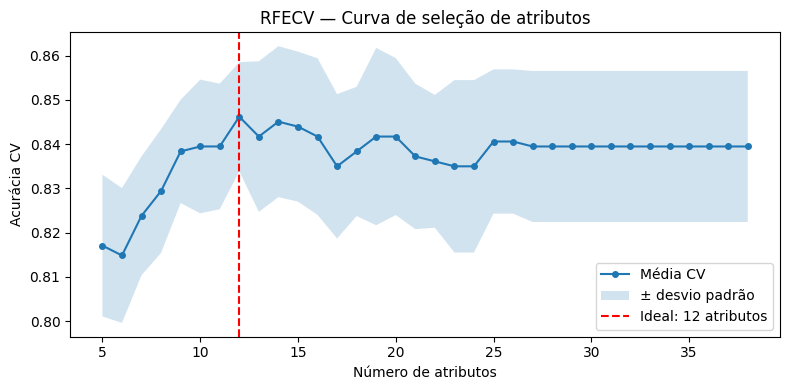

In [6]:
# ── 5b. Seleção de atributos com RFECV ───────────────────────────────────────
# O RFECV elimina recursivamente os atributos menos importantes
# e usa validação cruzada para encontrar o número ideal automaticamente

print(f"Atributos antes da seleção: {X.shape[1]}")

# XGBoost como estimador base (mais rápido que Floresta Aleatória)
rfecv = RFECV(
    estimator=XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        random_state=ESTADO_ALEATORIO,
        eval_metric='logloss'
    ),
    step=1,                   # elimina 1 atributo por iteração
    cv=VC,
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)
rfecv.fit(X, y)

# Aplica a máscara de seleção
X_sel      = X.loc[:, rfecv.support_]
X_test_sel = X_test.loc[:, rfecv.support_]

atribs_removidos = list(X.columns[~rfecv.support_])
atribs_mantidos  = list(X.columns[rfecv.support_])

print(f"Atributos após seleção: {X_sel.shape[1]}")
print(f"Removidos ({len(atribs_removidos)}): {atribs_removidos}")
print(f"Mantidos  ({len(atribs_mantidos)}): {atribs_mantidos}")
print(f"Acurácia CV com atributos selecionados: {rfecv.cv_results_['mean_test_score'][rfecv.n_features_ - rfecv.min_features_to_select]:.4f}")

# Substitui X e X_test pelos conjuntos após seleção
X      = X_sel
X_test = X_test_sel

# Gráfico da curva de seleção
min_f     = rfecv.min_features_to_select
medias    = rfecv.cv_results_['mean_test_score']
desvios   = rfecv.cv_results_['std_test_score']
intervalo = range(min_f, len(medias) + min_f)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(intervalo, medias, marker='o', markersize=4, label='Média CV')
ax.fill_between(
    intervalo,
    medias - desvios,
    medias + desvios,
    alpha=0.2, label='± desvio padrão'
)
ax.axvline(
    rfecv.n_features_, color='red', linestyle='--',
    label=f'Ideal: {rfecv.n_features_} atributos'
)
ax.set_xlabel('Número de atributos')
ax.set_ylabel('Acurácia CV')
ax.set_title('RFECV — Curva de seleção de atributos')
ax.legend()
plt.tight_layout()
plt.savefig('curva_rfecv.png', dpi=120)
plt.show()

In [7]:
# ── 6. Ajuste de hiperparâmetros ──────────────────────────────────────────────
# GridSearchCV com StratifiedKFold para cada modelo individualmente

# ── 6a. Floresta Aleatória ────────────────────────────────────────────────────
print("=" * 50)
print("Ajustando Floresta Aleatória...")

grid_fa = GridSearchCV(
    RandomForestClassifier(random_state=ESTADO_ALEATORIO),
    param_grid={
        'n_estimators':      [200, 300],
        'max_depth':         [4, 5, 6],
        'min_samples_split': [2, 5],
        'max_features':      ['sqrt', 'log2']
    },
    cv=VC, scoring='accuracy', n_jobs=-1
)
grid_fa.fit(X, y)
melhor_fa = grid_fa.best_estimator_
print(f"Melhores parâmetros FA: {grid_fa.best_params_}")
print(f"Acurácia CV FA:         {grid_fa.best_score_:.4f}")

Ajustando Floresta Aleatória...
Melhores parâmetros FA: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Acurácia CV FA:         0.8328


In [8]:
# ── 6b. XGBoost ──────────────────────────────────────────────────────────────
print("=" * 50)
print("Ajustando XGBoost...")

grid_xgb = GridSearchCV(
    XGBClassifier(
        random_state=ESTADO_ALEATORIO,
        eval_metric='logloss'
    ),
    param_grid={
        'n_estimators':     [200, 300],
        'max_depth':        [3, 4, 5],
        'learning_rate':    [0.05, 0.1],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    },
    cv=VC, scoring='accuracy', n_jobs=-1
)
grid_xgb.fit(X, y)
melhor_xgb = grid_xgb.best_estimator_
print(f"Melhores parâmetros XGB: {grid_xgb.best_params_}")
print(f"Acurácia CV XGB:         {grid_xgb.best_score_:.4f}")

Ajustando XGBoost...
Melhores parâmetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 1.0}
Acurácia CV XGB:         0.8462


In [9]:
# ── 6c. LightGBM ─────────────────────────────────────────────────────────────
print("=" * 50)
print("Ajustando LightGBM...")

grid_lgb = GridSearchCV(
    LGBMClassifier(random_state=ESTADO_ALEATORIO, verbose=-1),
    param_grid={
        'n_estimators':  [200, 300],
        'max_depth':     [4, 5, 6],
        'learning_rate': [0.05, 0.1],
        'num_leaves':    [31, 63],
        'subsample':     [0.8, 1.0]
    },
    cv=VC, scoring='accuracy', n_jobs=-1
)
grid_lgb.fit(X, y)
melhor_lgb = grid_lgb.best_estimator_
print(f"Melhores parâmetros LGB: {grid_lgb.best_params_}")
print(f"Acurácia CV LGB:         {grid_lgb.best_score_:.4f}")

Ajustando LightGBM...
Melhores parâmetros LGB: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}
Acurácia CV LGB:         0.8272


In [10]:
# ── 7. Conjunto de modelos (Ensemble) ─────────────────────────────────────────

# ── 7a. Votação suave (média das probabilidades dos 3 modelos) ────────────────
print("=" * 50)
print("Votação suave...")

votacao = VotingClassifier(
    estimators=[
        ('fa',  melhor_fa),
        ('xgb', melhor_xgb),
        ('lgb', melhor_lgb)
    ],
    voting='soft'
)

scores_votacao = cross_val_score(votacao, X, y, cv=VC, scoring='accuracy')
print(f"Acurácia CV Votação: {scores_votacao.mean():.4f} ± {scores_votacao.std():.4f}")

Votação suave...
Acurácia CV Votação: 0.8361 ± 0.0177


In [11]:
# ── 7b. Empilhamento (meta-modelo = Regressão Logística) ─────────────────────
print("=" * 50)
print("Empilhamento de modelos...")

empilhamento = StackingClassifier(
    estimators=[
        ('fa',  melhor_fa),
        ('xgb', melhor_xgb),
        ('lgb', melhor_lgb)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=ESTADO_ALEATORIO),
    passthrough=False,  # meta-modelo recebe apenas as predições dos modelos base
    cv=5
)

scores_empilhamento = cross_val_score(empilhamento, X, y, cv=VC, scoring='accuracy')
print(f"Acurácia CV Empilhamento: {scores_empilhamento.mean():.4f} ± {scores_empilhamento.std():.4f}")

Empilhamento de modelos...
Acurácia CV Empilhamento: 0.8428 ± 0.0180


In [12]:
# ── 7c. Comparação final entre todos os modelos ───────────────────────────────
resultados = pd.DataFrame({
    'Modelo': ['Floresta Aleatória', 'XGBoost', 'LightGBM', 'Votação suave', 'Empilhamento'],
    'Acurácia CV': [
        grid_fa.best_score_,
        grid_xgb.best_score_,
        grid_lgb.best_score_,
        scores_votacao.mean(),
        scores_empilhamento.mean()
    ],
    'Desvio Padrão': [
        grid_fa.cv_results_['std_test_score'][grid_fa.best_index_],
        grid_xgb.cv_results_['std_test_score'][grid_xgb.best_index_],
        grid_lgb.cv_results_['std_test_score'][grid_lgb.best_index_],
        scores_votacao.std(),
        scores_empilhamento.std()
    ]
}).sort_values('Acurácia CV', ascending=False).reset_index(drop=True)

print(resultados.to_string(index=False))

            Modelo  Acurácia CV  Desvio Padrão
           XGBoost     0.846218       0.012341
      Empilhamento     0.842847       0.017958
     Votação suave     0.836118       0.017721
Floresta Aleatória     0.832754       0.011694
          LightGBM     0.827167       0.016359


In [13]:
# ── 8. Treinar modelo final e gerar submissão ─────────────────────────────────
# Seleciona automaticamente o modelo com maior acurácia CV

nome_melhor  = resultados.iloc[0]['Modelo']
score_melhor = resultados.iloc[0]['Acurácia CV']
print(f"Melhor modelo: {nome_melhor} ({score_melhor:.4f})")

# Mapeia o nome para o objeto correspondente
mapa_modelos = {
    'Floresta Aleatória': melhor_fa,
    'XGBoost':            melhor_xgb,
    'LightGBM':           melhor_lgb,
    'Votação suave':      votacao,
    'Empilhamento':       empilhamento
}
modelo_final = mapa_modelos[nome_melhor]

# Treina com todos os dados de treino disponíveis
modelo_final.fit(X, y)
previsoes = modelo_final.predict(X_test)

submissao = pd.DataFrame({
    "PassengerId": teste["PassengerId"],
    "Survived":    previsoes
})

submissao.to_csv("submissao.csv", index=False)
print(f"\nSubmissão gerada com {len(submissao)} linhas.")
submissao.head(10)

Melhor modelo: XGBoost (0.8462)

Submissão gerada com 418 linhas.


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


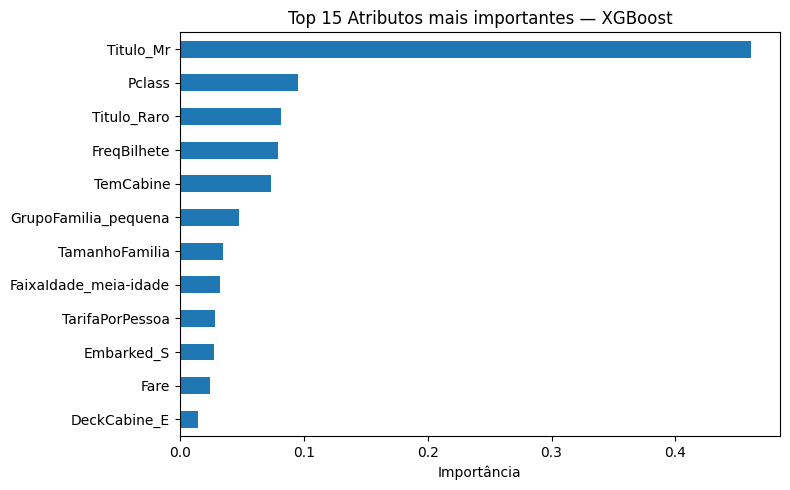

Titulo_Mr                0.461363
Pclass                   0.095022
Titulo_Raro              0.081408
FreqBilhete              0.078834
TemCabine                0.073713
GrupoFamilia_pequena     0.047590
TamanhoFamilia           0.034507
FaixaIdade_meia-idade    0.032223
TarifaPorPessoa          0.028121
Embarked_S               0.027868
Fare                     0.024510
DeckCabine_E             0.014841
dtype: float32


In [14]:
# ── Bônus: Importância dos atributos (XGBoost) ────────────────────────────────

melhor_xgb.fit(X, y)  # garante que está treinado com todos os dados

importancia = pd.Series(
    melhor_xgb.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
importancia.plot(kind='barh', ax=ax)
ax.set_title('Top 15 Atributos mais importantes — XGBoost')
ax.set_xlabel('Importância')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('importancia_atributos.png', dpi=120)
plt.show()
print(importancia)